# 🎙️ Speech Emotion Recognition
## Implementasi Model Hybrid Deep Learning Berbasis CNN-BiLSTM untuk Pemrosesan Sinyal Audio dalam Klasifikasi 8 Emosi Dasar Manusia menggunakan Dataset RAVDESS

**Nama:** Firgiansyah Wirapratama  
**NIM:** 221344012  
**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)  
**Model:** CNN-BiLSTM Hybrid  

---

### 📌 Deskripsi Project
Project ini mengimplementasikan sistem pengenalan emosi dari sinyal suara (Speech Emotion Recognition / SER) menggunakan pendekatan deep learning. Audio direpresentasikan sebagai **Mel-Spectrogram** dan **MFCC**, kemudian diproses oleh arsitektur hybrid **CNN-BiLSTM** yang mampu mengekstrak fitur spasial sekaligus temporal dari sinyal suara.

**Emosi yang dikenali:** Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, Surprised


## 0️⃣ Instalasi Library

> **Jalankan cell ini sekali saja.** Jika sudah terinstall, bisa di-skip.


In [28]:
import subprocess, sys

packages = [
    'librosa==0.10.1',
    'kaggle',
    'seaborn',
    'soundfile',
    'tqdm'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Semua library berhasil diinstall!')

✅ Semua library berhasil diinstall!


## 1️⃣ Setup Kaggle API & Download Dataset

### 📥 Cara Mendapatkan `kaggle.json`:
1. Login ke [kaggle.com](https://www.kaggle.com)
2. Klik foto profil → **Settings**
3. Scroll ke bagian **API** → klik **"Create New Token"**
4. File `kaggle.json` akan ter-download otomatis
5. **Letakkan file `kaggle.json` di folder yang sama dengan notebook ini**

> ⚠️ Jika menggunakan **Google Colab**, jalankan cell ini dan ikuti instruksi upload yang muncul.


In [29]:
import os

# Set kredensial langsung tanpa upload file
os.environ['KAGGLE_USERNAME'] = "firgiansyahw22"
os.environ['KAGGLE_KEY'] = "4a9caeb208dbe32329e3aafec7a864ad" # Token yang kamu kasih tadi

# Buat folder konfigurasi agar library kaggle bisa baca
kaggle_path = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_path, exist_ok=True)

with open(os.path.join(kaggle_path, 'kaggle.json'), 'w') as f:
    f.write(f'{{"username":"{os.environ["KAGGLE_USERNAME"]}", "key":"{os.environ["KAGGLE_KEY"]}"}}')

os.chmod(os.path.join(kaggle_path, 'kaggle.json'), 0o600)
print("✅ Kaggle API siap pake tanpa upload manual!")

✅ Kaggle API siap pake tanpa upload manual!


In [30]:
import zipfile

DATASET_DIR = 'dataset'
RAVDESS_DIR = os.path.join(DATASET_DIR, 'ravdess')

if os.path.exists(RAVDESS_DIR) and len(os.listdir(RAVDESS_DIR)) > 0:
    print(f'✅ Dataset sudah ada di: {RAVDESS_DIR}')
else:
    print('📥 Mendownload dataset RAVDESS dari Kaggle...')
    os.makedirs(RAVDESS_DIR, exist_ok=True)
    os.system(f'kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p {DATASET_DIR}')
    zip_path = os.path.join(DATASET_DIR, 'ravdess-emotional-speech-audio.zip')
    if os.path.exists(zip_path):
        print('📦 Mengekstrak file zip...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(RAVDESS_DIR)
        os.remove(zip_path)
        print('✅ Ekstraksi selesai.')
    else:
        print('⚠️ File zip tidak ditemukan. Cek koneksi / Kaggle API kamu.')

# Hitung file audio
audio_files = []
for root, dirs, files_list in os.walk(RAVDESS_DIR):
    for f in files_list:
        if f.endswith('.wav'):
            audio_files.append(os.path.join(root, f))

print(f'🎵 Total file audio ditemukan: {len(audio_files)} file')

✅ Dataset sudah ada di: dataset/ravdess
🎵 Total file audio ditemukan: 2880 file


## 2️⃣ Import Library & Konfigurasi


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import warnings
from tqdm import tqdm
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ TensorFlow  : {tf.__version__}')
print(f'✅ Librosa     : {librosa.__version__}')
print(f'✅ NumPy       : {np.__version__}')

gpus = tf.config.list_physical_devices('GPU')
print(f'🚀 GPU         : {gpus if gpus else "Tidak ada (CPU mode)"}')

✅ TensorFlow  : 2.20.0
✅ Librosa     : 0.10.1
✅ NumPy       : 2.0.2
🚀 GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
# ============================================================
# KONFIGURASI GLOBAL
# ============================================================
SAMPLE_RATE   = 22050
DURATION      = 3
N_MFCC        = 40
N_MELS        = 128
HOP_LENGTH    = 512
N_FFT         = 2048

BATCH_SIZE    = 32
EPOCHS        = 50
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2
TEST_SPLIT    = 0.1

# Mapping kode emosi RAVDESS (digit ke-3 pada nama file)
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

print('✅ Konfigurasi dimuat:')
print(f'   Sample Rate  : {SAMPLE_RATE} Hz')
print(f'   Durasi Audio : {DURATION} detik')
print(f'   N_MFCC       : {N_MFCC}')
print(f'   Batch Size   : {BATCH_SIZE}')
print(f'   Max Epochs   : {EPOCHS}')

✅ Konfigurasi dimuat:
   Sample Rate  : 22050 Hz
   Durasi Audio : 3 detik
   N_MFCC       : 40
   Batch Size   : 32
   Max Epochs   : 50


## 3️⃣ Exploratory Data Analysis (EDA)


In [33]:
def parse_ravdess_filename(filepath):
    """Parse nama file RAVDESS untuk mendapatkan label emosi."""
    fname = Path(filepath).stem
    parts = fname.split('-')
    return EMOTION_MAP.get(parts[2], 'unknown')

metadata = []
for fpath in audio_files:
    emotion = parse_ravdess_filename(fpath)
    metadata.append({
        'filepath': fpath,
        'emotion' : emotion,
        'actor'   : Path(fpath).parent.name
    })

df = pd.DataFrame(metadata)
print(f'Total sampel  : {len(df)}')
print(f'Jumlah emosi  : {df["emotion"].nunique()}')
print(f'Jumlah aktor  : {df["actor"].nunique()}')
df.head(8)

Total sampel  : 2880
Jumlah emosi  : 8
Jumlah aktor  : 24


,filepath,emotion,actor
0,dataset/ravdess/Actor_04/03-01-06-02-02-02-04.wav,fearful,Actor_04
1,dataset/ravdess/Actor_04/03-01-06-01-01-01-04.wav,fearful,Actor_04
2,dataset/ravdess/Actor_04/03-01-04-01-02-02-04.wav,sad,Actor_04
3,dataset/ravdess/Actor_04/03-01-03-01-01-02-04.wav,happy,Actor_04
4,dataset/ravdess/Actor_04/03-01-01-01-01-01-04.wav,neutral,Actor_04
5,dataset/ravdess/Actor_04/03-01-07-02-02-02-04.wav,disgust,Actor_04
6,dataset/ravdess/Actor_04/03-01-02-02-02-02-04.wav,calm,Actor_04
7,dataset/ravdess/Actor_04/03-01-06-02-01-01-04.wav,fearful,Actor_04


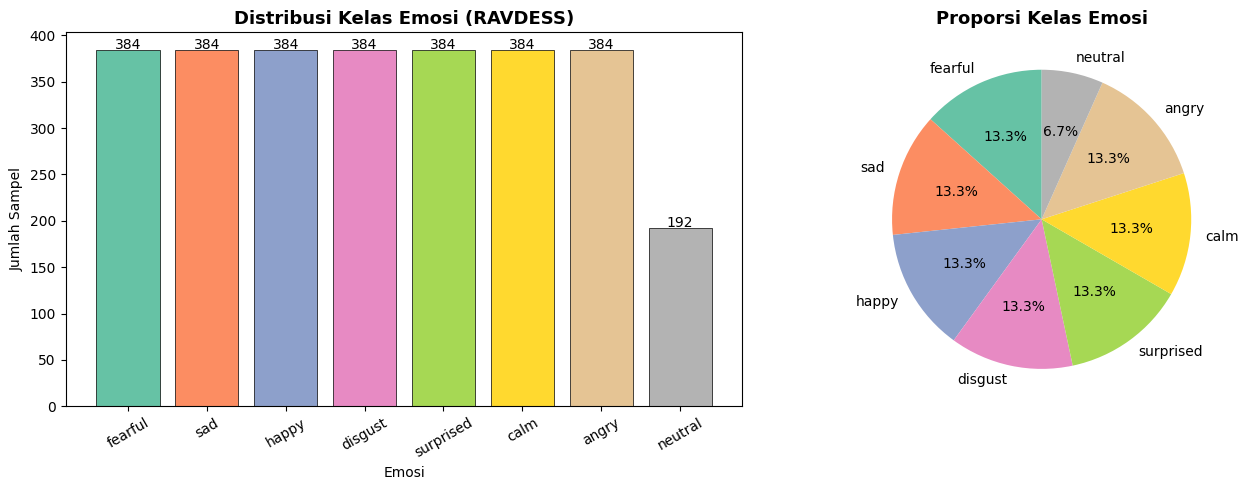

✅ Grafik distribusi emosi tersimpan.


In [34]:
# Distribusi kelas emosi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emotion_counts = df['emotion'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(emotion_counts)))

axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribusi Kelas Emosi (RAVDESS)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

axes[1].pie(emotion_counts.values, labels=emotion_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Kelas Emosi', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik distribusi emosi tersimpan.')

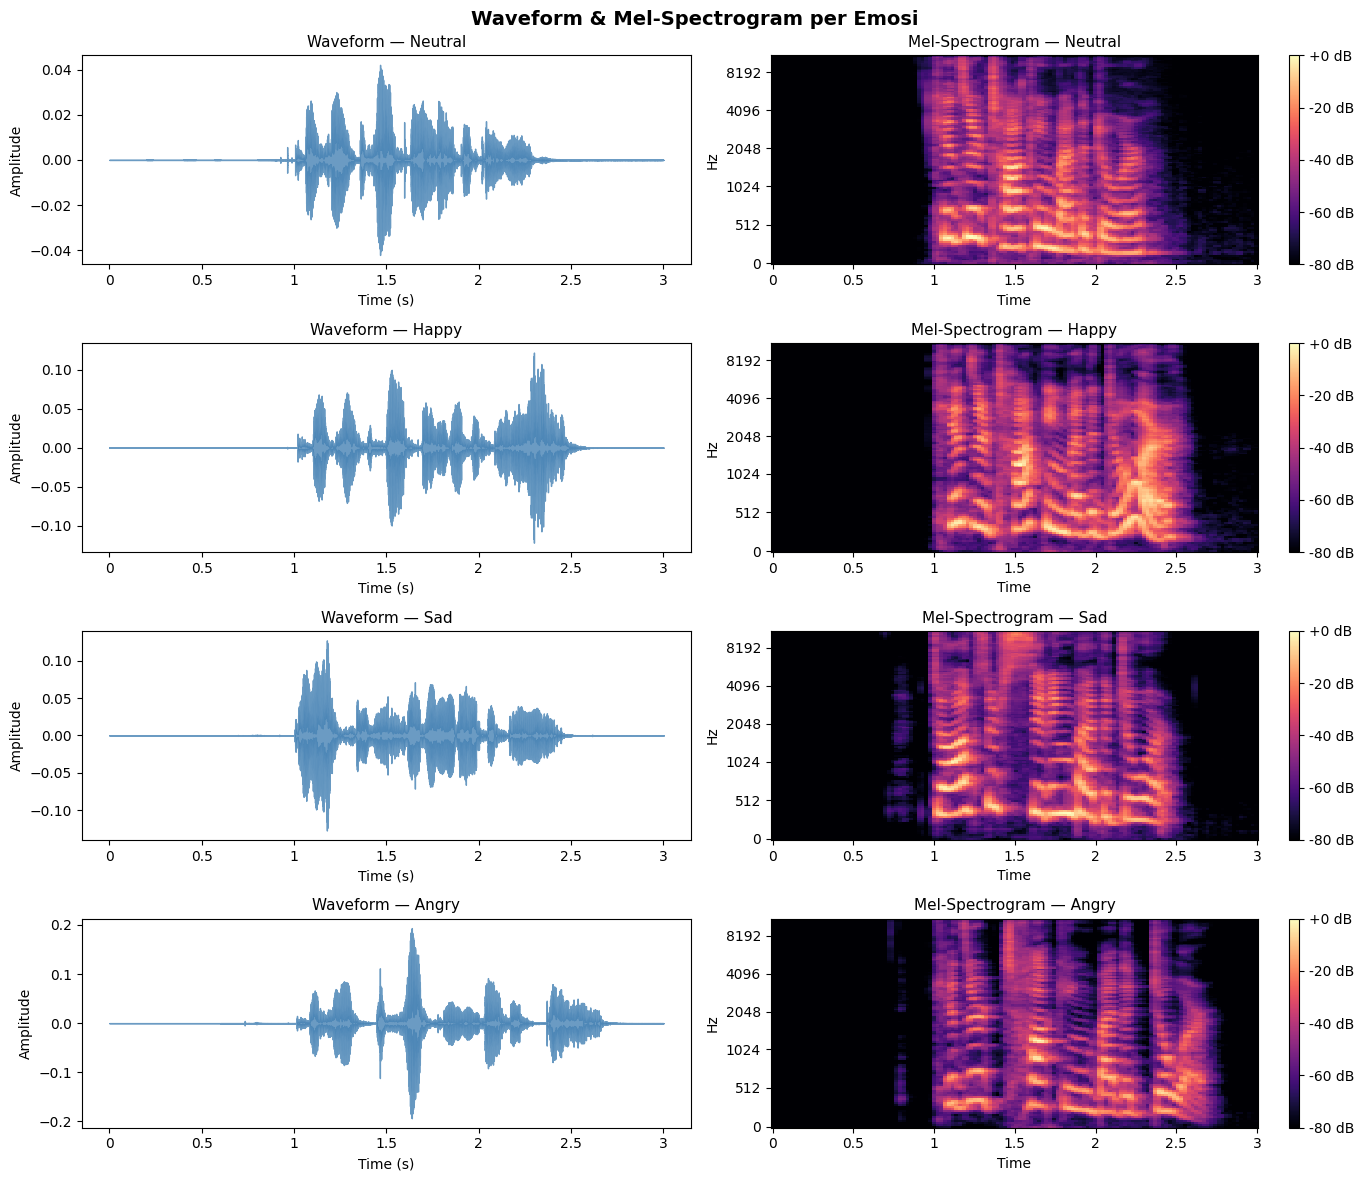

✅ Visualisasi waveform dan mel-spectrogram tersimpan.


In [35]:
# Visualisasi Waveform & Mel-Spectrogram per emosi
emotions_to_show = ['neutral', 'happy', 'sad', 'angry']
fig, axes = plt.subplots(len(emotions_to_show), 2, figsize=(14, 12))
fig.suptitle('Waveform & Mel-Spectrogram per Emosi', fontsize=14, fontweight='bold')

for i, emotion in enumerate(emotions_to_show):
    sample_path = df[df['emotion'] == emotion]['filepath'].iloc[0]
    y, sr = librosa.load(sample_path, sr=SAMPLE_RATE, duration=DURATION)

    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], color='steelblue', alpha=0.8)
    axes[i, 0].set_title(f'Waveform — {emotion.capitalize()}', fontsize=11)
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')

    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS), ref=np.max)
    img = librosa.display.specshow(mel, sr=sr, hop_length=HOP_LENGTH,
                                   x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'Mel-Spectrogram — {emotion.capitalize()}', fontsize=11)
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('eda_waveform_melspec.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi waveform dan mel-spectrogram tersimpan.')

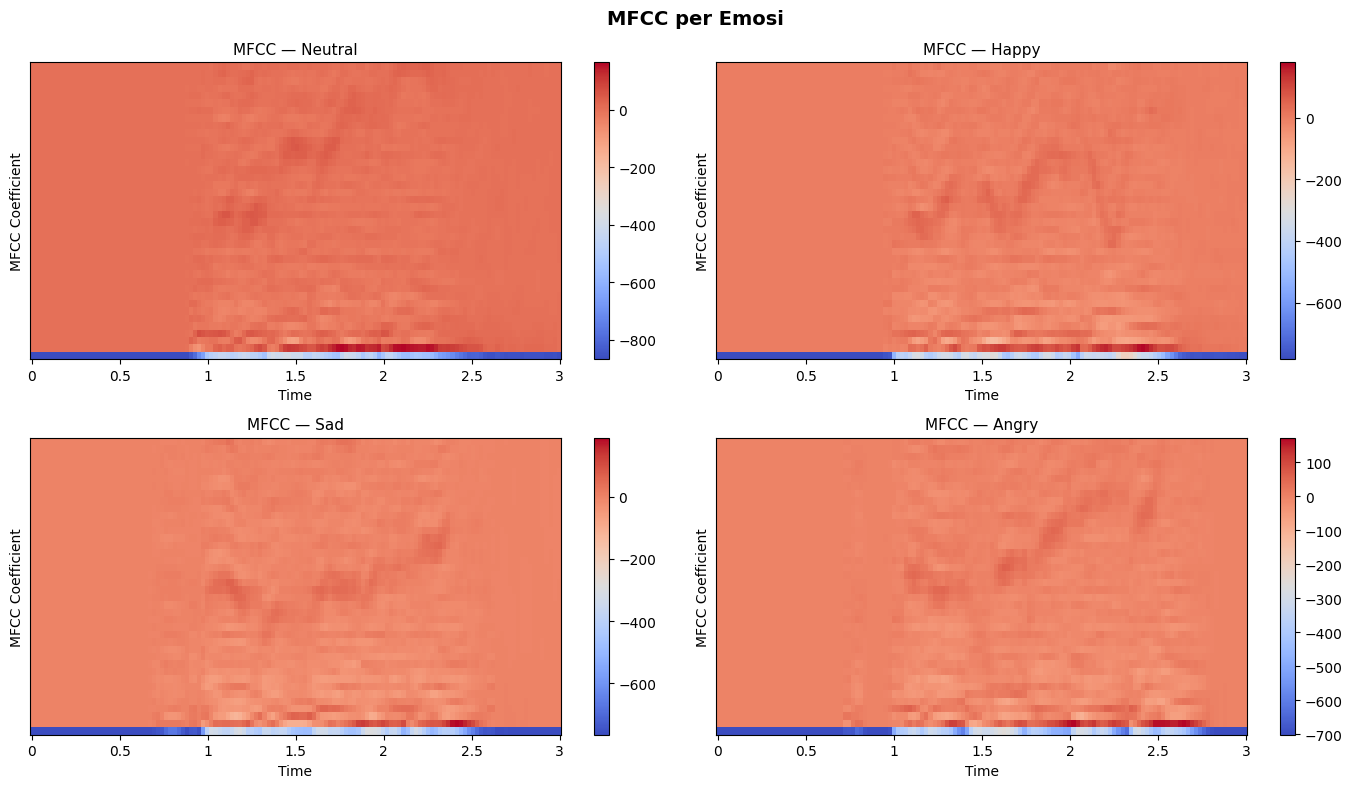

✅ Visualisasi MFCC tersimpan.


In [36]:
# Visualisasi MFCC per emosi
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('MFCC per Emosi', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, emotion in enumerate(emotions_to_show):
    sample_path = df[df['emotion'] == emotion]['filepath'].iloc[0]
    y, sr = librosa.load(sample_path, sr=SAMPLE_RATE, duration=DURATION)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    img = librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LENGTH, x_axis='time', ax=axes[i])
    axes[i].set_title(f'MFCC — {emotion.capitalize()}', fontsize=11)
    axes[i].set_ylabel('MFCC Coefficient')
    fig.colorbar(img, ax=axes[i])

plt.tight_layout()
plt.savefig('eda_mfcc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi MFCC tersimpan.')

## 4️⃣ Feature Extraction

Fitur yang diekstrak dari setiap file audio:
- **MFCC** — representasi kompak spektrum suara manusia
- **Delta MFCC** — turunan pertama (laju perubahan)
- **Delta-Delta MFCC** — turunan kedua (akselerasi perubahan)
- **Mel-Spectrogram** — energi frekuensi dalam skala mel

Keempat fitur digabungkan menjadi satu representasi: shape `(time_steps, 160)`


In [37]:
def extract_features(filepath):
    """
    Ekstrak fitur gabungan dari file audio WAV.

    Returns:
        np.ndarray shape (time_steps, 160) atau None jika error
    """
    try:
        y, sr = librosa.load(filepath, sr=SAMPLE_RATE, duration=DURATION)

        # Padding / Truncating
        target_len = SAMPLE_RATE * DURATION
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)), mode='constant')
        else:
            y = y[:target_len]

        mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        delta       = librosa.feature.delta(mfcc)
        delta2      = librosa.feature.delta(mfcc, order=2)
        mel         = librosa.power_to_db(
                          librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MFCC, hop_length=HOP_LENGTH),
                          ref=np.max)

        combined = np.vstack([mfcc, delta, delta2, mel]).T  # (T, 160)
        return combined

    except Exception as e:
        print(f'⚠️ Error pada {filepath}: {e}')
        return None

# Test
test = extract_features(df['filepath'].iloc[0])
print(f'✅ Shape fitur 1 sampel: {test.shape}  →  (time_steps, n_features)')

✅ Shape fitur 1 sampel: (130, 160)  →  (time_steps, n_features)


In [38]:
CACHE_FILE = 'features_cache.npz'

if os.path.exists(CACHE_FILE):
    print('📂 Memuat fitur dari cache...')
    cache    = np.load(CACHE_FILE, allow_pickle=True)
    X        = cache['X']
    y_labels = cache['y_labels']
    print(f'✅ Cache dimuat. Shape X: {X.shape}')
else:
    print('⚙️ Mengekstrak fitur... (beberapa menit pada CPU)')
    X_list, y_list = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Feature Extraction'):
        feat = extract_features(row['filepath'])
        if feat is not None:
            X_list.append(feat)
            y_list.append(row['emotion'])

    X        = np.array(X_list)
    y_labels = np.array(y_list)
    np.savez_compressed(CACHE_FILE, X=X, y_labels=y_labels)
    print('✅ Fitur diekstrak dan disimpan ke cache.')

print(f'📊 Shape X        : {X.shape}')
print(f'📊 Shape y_labels : {y_labels.shape}')
print(f'📊 Distribusi     : {dict(Counter(y_labels))}')

📂 Memuat fitur dari cache...
✅ Cache dimuat. Shape X: (2880, 130, 160)
📊 Shape X        : (2880, 130, 160)
📊 Shape y_labels : (2880,)
📊 Distribusi     : {np.str_('fearful'): 384, np.str_('sad'): 384, np.str_('happy'): 384, np.str_('neutral'): 192, np.str_('disgust'): 384, np.str_('calm'): 384, np.str_('surprised'): 384, np.str_('angry'): 384}


## 5️⃣ Preprocessing & Data Splitting


In [39]:
# Label encoding
le          = LabelEncoder()
y_encoded   = le.fit_transform(y_labels)
y_cat       = to_categorical(y_encoded)
NUM_CLASSES = len(le.classes_)

print(f'Kelas emosi   : {list(le.classes_)}')
print(f'Jumlah kelas  : {NUM_CLASSES}')
print(f'Shape y (OHE) : {y_cat.shape}')

Kelas emosi   : [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Jumlah kelas  : 8
Shape y (OHE) : (2880, 8)


In [40]:
# Normalisasi StandardScaler per feature dimension
N, T, F   = X.shape
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

print(f'✅ Normalisasi selesai.')
print(f'   Mean (sesudah): {X_scaled.reshape(-1, F).mean():.4f}')
print(f'   Std  (sesudah): {X_scaled.reshape(-1, F).std():.4f}')

✅ Normalisasi selesai.
   Mean (sesudah): -0.0000
   Std  (sesudah): 1.0000


In [41]:
# Train / Validation / Test split (stratified)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_cat, test_size=TEST_SPLIT, random_state=42, stratify=y_encoded)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VALIDATION_SPLIT,
    random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f'✅ Split selesai (total {N} sampel):')
print(f'   Train : {X_train.shape[0]} ({X_train.shape[0]/N*100:.1f}%)')
print(f'   Val   : {X_val.shape[0]}   ({X_val.shape[0]/N*100:.1f}%)')
print(f'   Test  : {X_test.shape[0]}   ({X_test.shape[0]/N*100:.1f}%)')

✅ Split selesai (total 2880 sampel):
   Train : 2073 (72.0%)
   Val   : 519   (18.0%)
   Test  : 288   (10.0%)


In [42]:
# Tambah dimensi channel untuk CNN: (N, T, F) → (N, T, F, 1)
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[...,   np.newaxis]
X_test_cnn  = X_test[...,  np.newaxis]

print(f'✅ Shape setelah reshape untuk CNN:')
print(f'   X_train : {X_train_cnn.shape}')
print(f'   X_val   : {X_val_cnn.shape}')
print(f'   X_test  : {X_test_cnn.shape}')

✅ Shape setelah reshape untuk CNN:
   X_train : (2073, 130, 160, 1)
   X_val   : (519, 130, 160, 1)
   X_test  : (288, 130, 160, 1)


## 6️⃣ Arsitektur Model CNN-BiLSTM

```
Input (time_steps, n_features, 1)
    ↓
CNN Block 1: Conv2D(32) → BN → MaxPool → Dropout
CNN Block 2: Conv2D(64) → BN → MaxPool → Dropout  
CNN Block 3: Conv2D(128) → BN → MaxPool → Dropout
    ↓
Reshape → (time_steps_baru, features_flat)
    ↓
BiLSTM Layer 1 (128 units, return_sequences=True)
BiLSTM Layer 2 (64 units, return_sequences=False)
    ↓
Dense(128) → BN → Dropout
Dense(64)  → Dropout
Output: Dense(N_kelas, softmax)
```


In [43]:
def build_cnn_bilstm(input_shape, num_classes, lr=LEARNING_RATE):
    inputs = keras.Input(shape=input_shape, name='audio_input')

    # CNN Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.MaxPooling2D((2,1), name='pool3')(x)
    x = layers.Dropout(0.25, name='drop3')(x)

    # Reshape untuk LSTM: (batch, T', F', C) → (batch, T', F'*C)
    s = x.shape
    x = layers.Reshape((s[1], s[2] * s[3]), name='reshape')(x)

    # BiLSTM
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True,  dropout=0.3, recurrent_dropout=0.2), name='bilstm1')(x)
    x = layers.Bidirectional(layers.LSTM(64,  return_sequences=False, dropout=0.3, recurrent_dropout=0.2), name='bilstm2')(x)

    # Dense
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Dropout(0.4, name='drop4')(x)
    x = layers.Dense(64, activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='drop5')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs, outputs, name='CNN_BiLSTM_SER')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

INPUT_SHAPE = X_train_cnn.shape[1:]
model = build_cnn_bilstm(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "CNN_BiLSTM_SER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_input (InputLayer)        │ (None, 130, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 130, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 130, 160, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 65, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 65, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 65, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 65, 80, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 40, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 5120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 16, 256)        │     5,374,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm2 (Bidirectional)         │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,658,696 (21.59 MB)

 Trainable params: 5,657,992 (21.58 MB)

 Non-trainable params: 704 (2.75 KB)

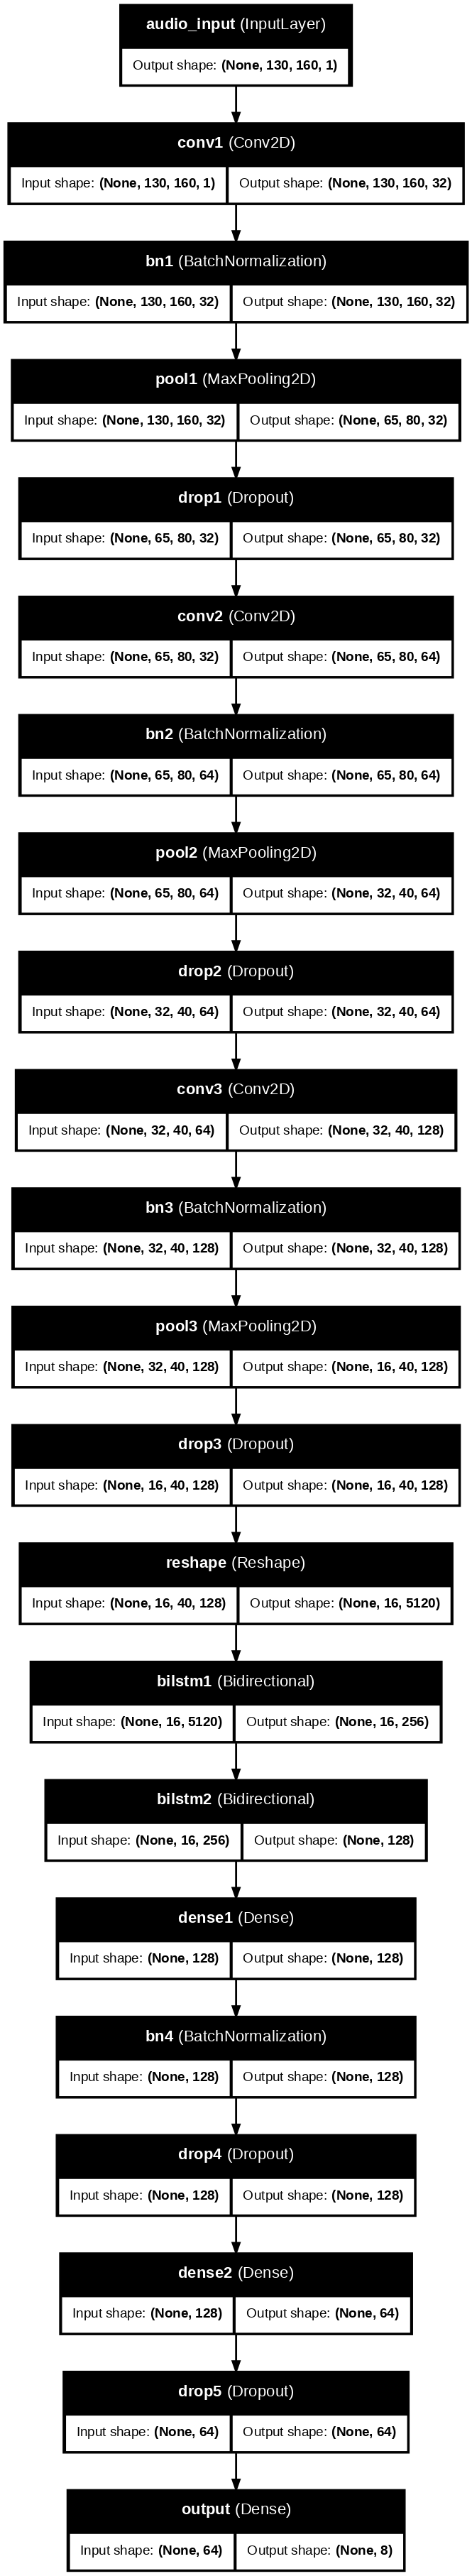

✅ Diagram arsitektur model tersimpan.


In [44]:
try:
    keras.utils.plot_model(model, to_file='model_architecture.png',
                           show_shapes=True, show_layer_names=True, dpi=100)
    from IPython.display import Image
    display(Image('model_architecture.png'))
    print('✅ Diagram arsitektur model tersimpan.')
except Exception as e:
    print(f'⚠️ plot_model tidak tersedia: {e}')

## 7️⃣ Training Model


In [45]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('🚀 Memulai training...')
print(f'   Epochs     : {EPOCHS} (dengan EarlyStopping)')
print(f'   Batch Size : {BATCH_SIZE}')
print(f'   Train      : {X_train_cnn.shape[0]} sampel')
print(f'   Val        : {X_val_cnn.shape[0]} sampel')

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Training selesai!')
print(f'   Best Val Accuracy : {max(history.history["val_accuracy"]):.4f}')

🚀 Memulai training...
   Epochs     : 50 (dengan EarlyStopping)
   Batch Size : 32
   Train      : 2073 sampel
   Val        : 519 sampel
Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.1577 - loss: 2.4992
Epoch 1: val_accuracy improved from None to 0.14644, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 303ms/step - accuracy: 0.1867 - loss: 2.3000 - val_accuracy: 0.1464 - val_loss: 2.1142 - learning_rate: 0.0010
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2544 - loss: 1.9797
Epoch 2: val_accuracy did not improve from 0.14644
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 287ms/step - accuracy: 0.2735 - loss: 1.9205 - val_accuracy: 0.1368 - val_loss: 2.1417 - learning_rate: 0.0010
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.3041 - loss: 1.8447
Epoch 3: val_accuracy did not improve from 0.14644
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.3126 - loss: 1.7883 - va

## 8️⃣ Evaluasi Model


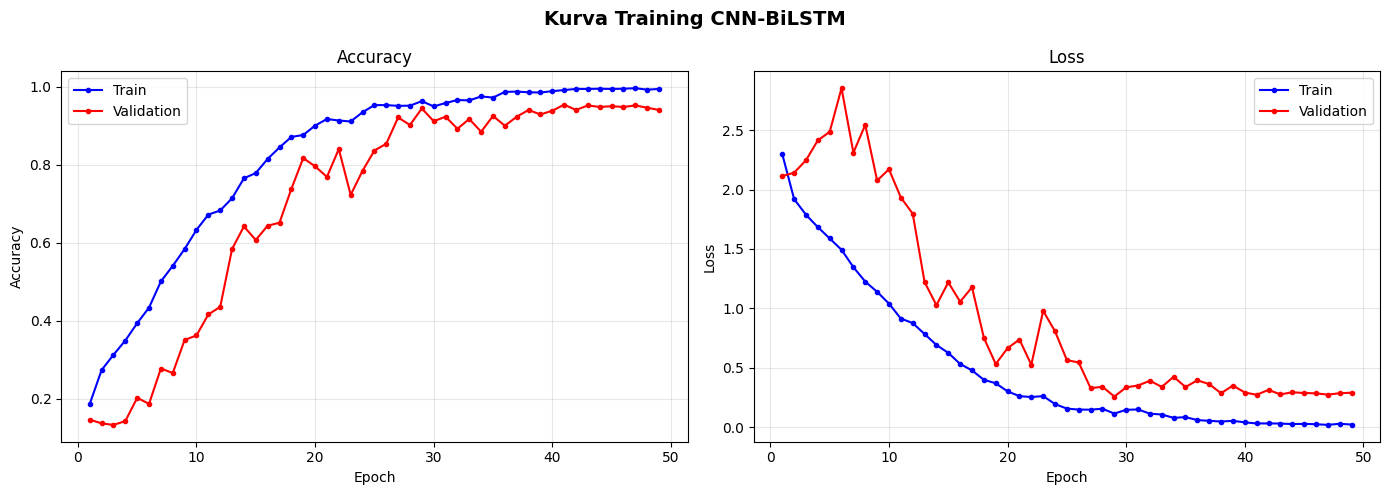

✅ Kurva training tersimpan.


In [46]:
# Kurva training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kurva Training CNN-BiLSTM', fontsize=14, fontweight='bold')
ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'],     'b-o', markersize=3, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 'r-o', markersize=3, label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history.history['loss'],     'b-o', markersize=3, label='Train')
axes[1].plot(ep, history.history['val_loss'], 'r-o', markersize=3, label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Kurva training tersimpan.')

In [47]:
# Evaluasi pada test set
best_model = keras.models.load_model('best_model.keras')
test_loss, test_acc = best_model.evaluate(X_test_cnn, y_test, verbose=0)

y_pred_prob = best_model.predict(X_test_cnn, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

print(f'🎯 Test Loss     : {test_loss:.4f}')
print(f'🎯 Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

🎯 Test Loss     : 0.3880
🎯 Test Accuracy : 0.9201 (92.01%)

📋 Classification Report:
              precision    recall  f1-score   support

       angry       1.00      0.95      0.97        38
        calm       0.86      1.00      0.93        38
     disgust       1.00      0.95      0.97        38
     fearful       0.89      0.85      0.87        39
       happy       0.92      0.92      0.92        39
     neutral       0.88      0.74      0.80        19
         sad       0.87      0.89      0.88        38
   surprised       0.93      0.97      0.95        39

    accuracy                           0.92       288
   macro avg       0.92      0.91      0.91       288
weighted avg       0.92      0.92      0.92       288



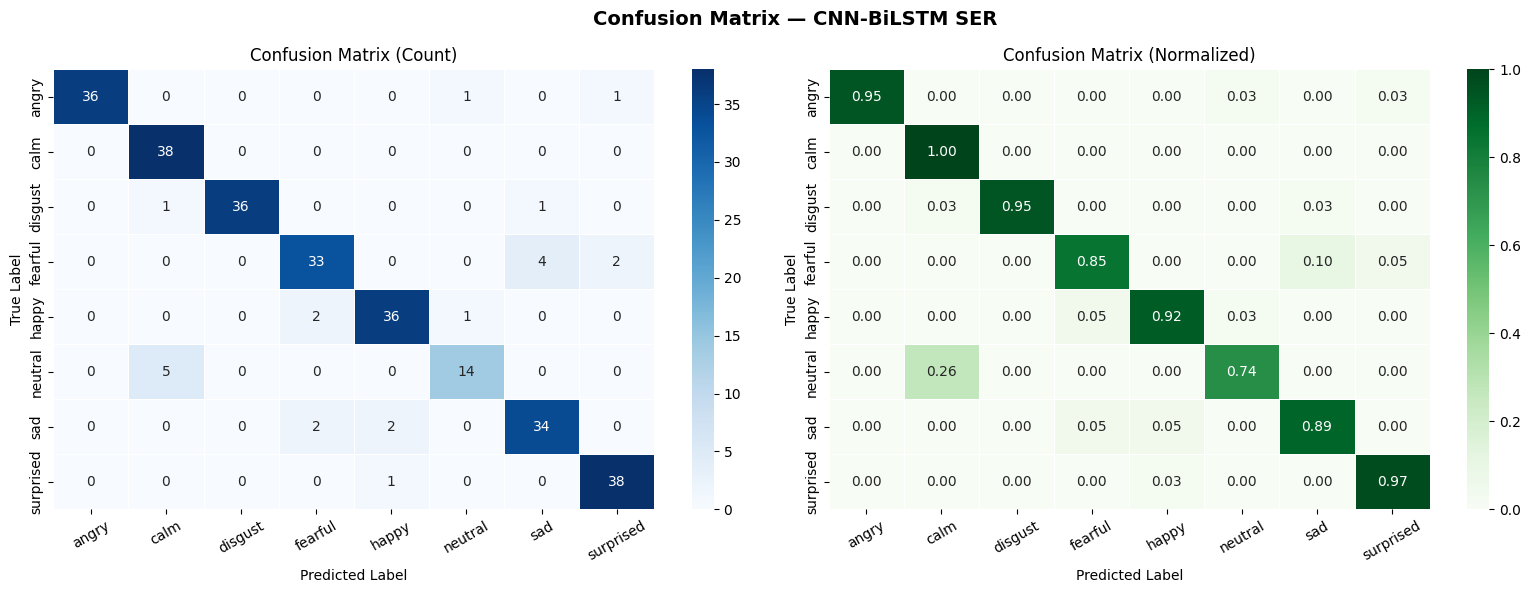

✅ Confusion matrix tersimpan.


In [48]:
# Confusion Matrix
cm            = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — CNN-BiLSTM SER', fontsize=14, fontweight='bold')

for ax, data, fmt, cmap, title in zip(
    axes,
    [cm, cm_normalized],
    ['d', '.2f'],
    ['Blues', 'Greens'],
    ['Count', 'Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix tersimpan.')

In [49]:
# Metrik per kelas
precision = precision_score(y_true, y_pred, average=None)
recall    = recall_score(y_true, y_pred, average=None)
f1        = f1_score(y_true, y_pred, average=None)

metrics_df = pd.DataFrame({
    'Emotion'  : le.classes_,
    'Precision': precision.round(4),
    'Recall'   : recall.round(4),
    'F1-Score' : f1.round(4)
})
print('📊 Metrik per Kelas:')
print(metrics_df.to_string(index=False))
print(f'\n📊 Weighted F1 : {f1_score(y_true, y_pred, average="weighted"):.4f}')
print(f'📊 Macro F1    : {f1_score(y_true, y_pred, average="macro"):.4f}')

📊 Metrik per Kelas:
  Emotion  Precision  Recall  F1-Score
    angry     1.0000  0.9474    0.9730
     calm     0.8636  1.0000    0.9268
  disgust     1.0000  0.9474    0.9730
  fearful     0.8919  0.8462    0.8684
    happy     0.9231  0.9231    0.9231
  neutral     0.8750  0.7368    0.8000
      sad     0.8718  0.8947    0.8831
surprised     0.9268  0.9744    0.9500

📊 Weighted F1 : 0.9196
📊 Macro F1    : 0.9122


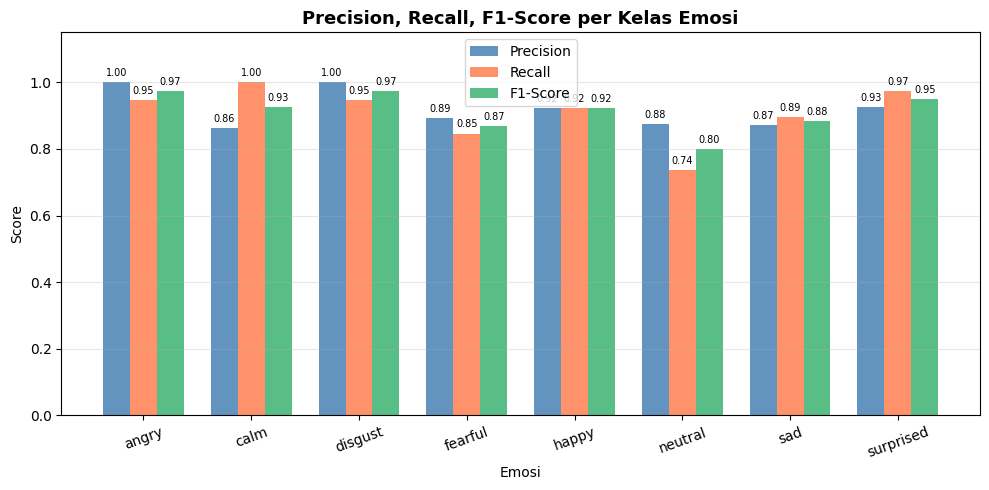

✅ Grafik metrik per kelas tersimpan.


In [50]:
# Visualisasi metrik per kelas
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(le.classes_))
w = 0.25

b1 = ax.bar(x - w, precision, w, label='Precision', color='steelblue',     alpha=0.85)
b2 = ax.bar(x,     recall,    w, label='Recall',    color='coral',         alpha=0.85)
b3 = ax.bar(x + w, f1,        w, label='F1-Score',  color='mediumseagreen',alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=20)
ax.set_ylim(0, 1.15)
ax.set_xlabel('Emosi'); ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1-Score per Kelas Emosi', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik metrik per kelas tersimpan.')

## 9️⃣ Demo Prediksi


In [51]:
def predict_emotion(filepath, model, scaler, label_encoder):
    """Prediksi emosi dari satu file audio WAV."""
    feat = extract_features(filepath)
    if feat is None:
        return None
    feat_scaled = scaler.transform(feat)
    feat_input  = feat_scaled[np.newaxis, ..., np.newaxis]
    probs       = model.predict(feat_input, verbose=0)[0]
    pred_idx    = np.argmax(probs)
    all_probs   = {label_encoder.classes_[i]: float(probs[i]) for i in range(len(probs))}
    return {
        'emotion'   : label_encoder.classes_[pred_idx],
        'confidence': float(probs[pred_idx]),
        'all_probs' : all_probs
    }

print('✅ Fungsi prediksi siap.')

✅ Fungsi prediksi siap.


🎬 Demo Prediksi
✅ True: happy        Pred: happy        Conf: 99.99%
✅ True: sad          Pred: sad          Conf: 99.98%
✅ True: angry        Pred: angry        Conf: 99.99%
✅ True: neutral      Pred: neutral      Conf: 87.99%


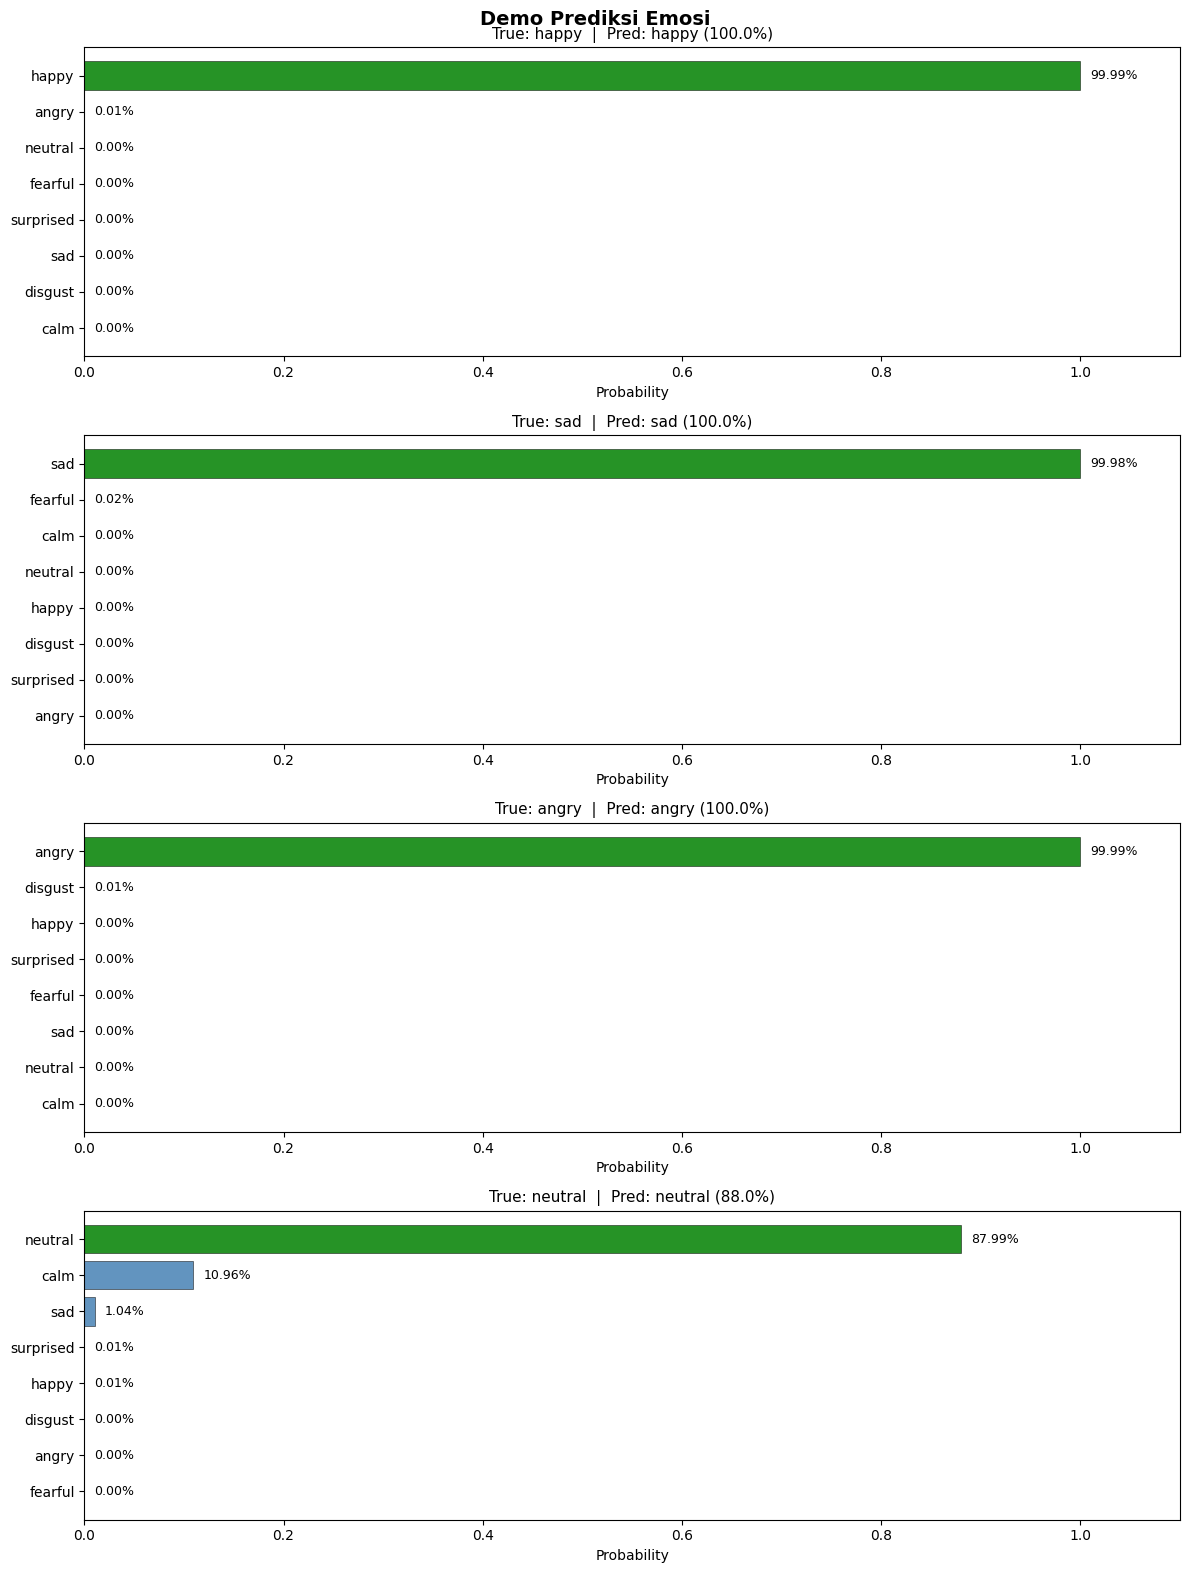


✅ Demo selesai.


In [52]:
# Demo: prediksi 4 sampel dari berbagai emosi
demo_emotions = ['happy', 'sad', 'angry', 'neutral']
fig, axes = plt.subplots(len(demo_emotions), 1, figsize=(12, 4 * len(demo_emotions)))
fig.suptitle('Demo Prediksi Emosi', fontsize=14, fontweight='bold')

print('🎬 Demo Prediksi\n' + '='*50)

for i, target_emotion in enumerate(demo_emotions):
    row      = df[df['emotion'] == target_emotion].iloc[5]
    result   = predict_emotion(row['filepath'], best_model, scaler, le)
    true_emo = row['emotion']
    status   = '✅' if result['emotion'] == true_emo else '❌'
    print(f'{status} True: {true_emo:<12} Pred: {result["emotion"]:<12} Conf: {result["confidence"]:.2%}')

    # Horizontal bar chart
    sorted_probs = sorted(result['all_probs'].items(), key=lambda x: -x[1])
    labels_bar   = [e[0] for e in sorted_probs]
    probs_bar    = [e[1] for e in sorted_probs]
    bar_colors   = ['green' if l == true_emo else ('tomato' if l == result['emotion'] and l != true_emo else 'steelblue')
                    for l in labels_bar]

    axes[i].barh(labels_bar, probs_bar, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.4)
    axes[i].set_xlim(0, 1.1)
    axes[i].set_title(f'True: {true_emo}  |  Pred: {result["emotion"]} ({result["confidence"]:.1%})', fontsize=11)
    axes[i].set_xlabel('Probability')
    for j, prob in enumerate(probs_bar):
        axes[i].text(prob + 0.01, j, f'{prob:.2%}', va='center', fontsize=9)
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig('demo_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Demo selesai.')

In [53]:
# Prediksi file audio custom (opsional)
# Ganti nilai di bawah dengan path file .wav milikmu
custom_audio_path = None  # contoh: 'rekaman_saya.wav'

if custom_audio_path and os.path.exists(custom_audio_path):
    result = predict_emotion(custom_audio_path, best_model, scaler, le)
    print(f'🎙️ File    : {os.path.basename(custom_audio_path)}')
    print(f'🎭 Emosi   : {result["emotion"].upper()} (confidence: {result["confidence"]:.2%})')
    print(f'📊 Semua probabilitas:')
    for emo, prob in sorted(result['all_probs'].items(), key=lambda x: -x[1]):
        bar = '█' * int(prob * 20)
        print(f'   {emo:<12}: {bar:<20} {prob:.2%}')
else:
    print('ℹ️  custom_audio_path tidak diisi. Prediksi file random dari dataset:')
    rand_row = df.sample(1, random_state=99).iloc[0]
    result   = predict_emotion(rand_row['filepath'], best_model, scaler, le)
    print(f'🎙️ File    : {os.path.basename(rand_row["filepath"])}')
    print(f'🏷️  True    : {rand_row["emotion"].upper()}')
    print(f'🎭 Prediksi: {result["emotion"].upper()} (confidence: {result["confidence"]:.2%})')

ℹ️  custom_audio_path tidak diisi. Prediksi file random dari dataset:
🎙️ File    : 03-01-05-01-02-01-09.wav
🏷️  True    : ANGRY
🎭 Prediksi: ANGRY (confidence: 99.95%)


## 🏁 Kesimpulan


In [54]:
final_acc        = accuracy_score(y_true, y_pred)
final_f1_w       = f1_score(y_true, y_pred, average='weighted')
final_f1_m       = f1_score(y_true, y_pred, average='macro')
total_params     = model.count_params()

print('=' * 55)
print('  📋 RINGKASAN — SPEECH EMOTION RECOGNITION')
print('=' * 55)
print(f'  Dataset          : RAVDESS Emotional Speech Audio')
print(f'  Total Sampel     : {len(df)} file audio')
print(f'  Jumlah Kelas     : {NUM_CLASSES} emosi')
print(f'  Model            : CNN-BiLSTM Hybrid')
print(f'  Total Parameter  : {total_params:,}')
print(f'  Fitur            : MFCC + Delta + Delta2 + Mel-Spec')
print('-' * 55)
print(f'  Test Accuracy    : {final_acc:.4f} ({final_acc*100:.2f}%)')
print(f'  Weighted F1      : {final_f1_w:.4f}')
print(f'  Macro F1         : {final_f1_m:.4f}')
print('=' * 55)

output_files = [
    'eda_emotion_distribution.png',
    'eda_waveform_melspec.png',
    'eda_mfcc.png',
    'training_curves.png',
    'confusion_matrix.png',
    'metrics_per_class.png',
    'demo_predictions.png',
    'best_model.keras',
    'features_cache.npz'
]

print('\n  📁 Output files:')
for f in output_files:
    icon = '✅' if os.path.exists(f) else '⏳'
    print(f'    {icon} {f}')

  📋 RINGKASAN — SPEECH EMOTION RECOGNITION
  Dataset          : RAVDESS Emotional Speech Audio
  Total Sampel     : 2880 file audio
  Jumlah Kelas     : 8 emosi
  Model            : CNN-BiLSTM Hybrid
  Total Parameter  : 5,658,696
  Fitur            : MFCC + Delta + Delta2 + Mel-Spec
-------------------------------------------------------
  Test Accuracy    : 0.9201 (92.01%)
  Weighted F1      : 0.9196
  Macro F1         : 0.9122

  📁 Output files:
    ✅ eda_emotion_distribution.png
    ✅ eda_waveform_melspec.png
    ✅ eda_mfcc.png
    ✅ training_curves.png
    ✅ confusion_matrix.png
    ✅ metrics_per_class.png
    ✅ demo_predictions.png
    ✅ best_model.keras
    ✅ features_cache.npz
